## Literacy

### Average length of ads

Average length of ads = number of words in ads per year / number of ads per year

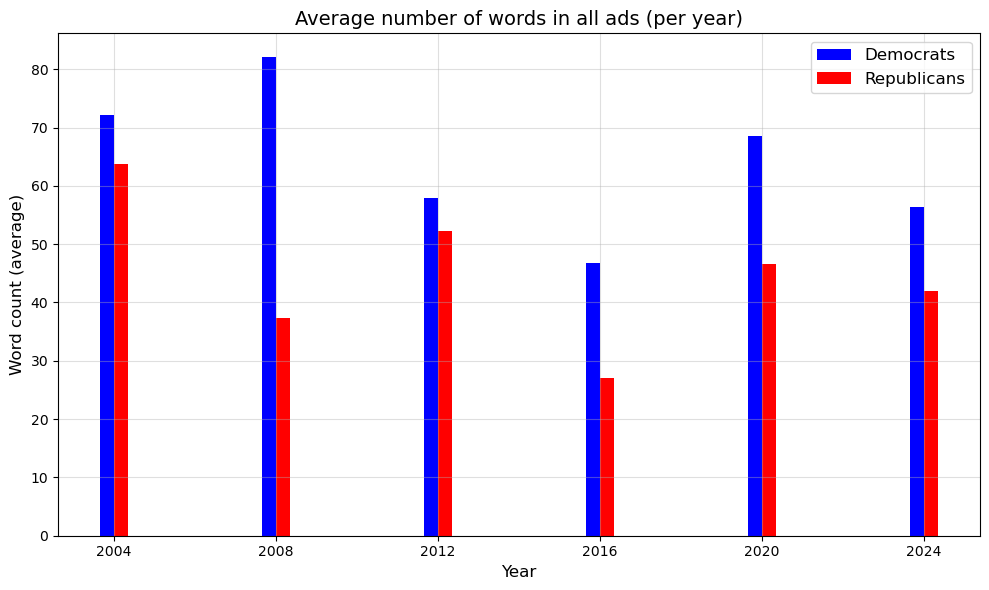

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_average_words(file_path):
    data = pd.read_csv(file_path)
    for col in data.columns[1:]:  #skip the year column when counting averages!!
        data[col] = data[col].fillna("").apply(lambda x: len(x.split())) #use the NaN, etc. to make sure empty cols aren't counted
    data["Average_Words"] = data.iloc[:, 1:].mean(axis=1)
    return data[["Year", "Average_Words"]].sort_values(by="Year")

file_dems = "/Users/inqsoncharoen/Documents/Election_Analysis/cleaned_dems.csv"
file_repub = "/Users/inqsoncharoen/Documents/Election_Analysis/cleaned_repub.csv"

avg_dems = calculate_average_words(file_dems)
avg_repub = calculate_average_words(file_repub)

merged = pd.merge(avg_dems, avg_repub, on="Year", suffixes=("_Dems", "_Repub")) #merge year column / match up, create avg. words

x = merged["Year"]
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, merged["Average_Words_Dems"], width=width, label="Democrats", color="blue")
plt.bar(x + width/2, merged["Average_Words_Repub"], width=width, label="Republicans", color="red")

plt.title("Average number of words in all ads (per year)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Word count (average)", fontsize=12)
plt.xticks(x, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


### Average length of words in ads

Average length of words = total characters / total number of words

In [ ]:
import pandas as pd

#func for avg word length
def calculate_average_word_length(file_path):
    data = pd.read_csv(file_path)
    
    data = data.fillna("") #Nan? Fill it with empty strings instead... important formatting unfortunately
    
    for col in data.columns[1:]: #skip year col
        data[col] = data[col].astype(str) #make all ad cols to strings
    
    data["Total_Characters"] = data.iloc[:, 1:].apply(lambda row: sum(len(str(ad)) for ad in row), axis=1) #total characters for all ads combined, per year
    
    data["Total_Words"] = data.iloc[:, 1:].apply(lambda row: sum(len(str(ad).split()) for ad in row), axis=1) #same but w/ words
    
    #avg word length
    data["Average_Word_Length"] = data.apply(
        lambda row: row["Total_Characters"] / row["Total_Words"] if row["Total_Words"] > 0 else 0,
        axis=1
    )
    
    return data[["Year", "Average_Word_Length"]]

file_dems = "/Users/inqsoncharoen/Documents/Election_Analysis/cleaned_dems.csv"
file_repub = "/Users/inqsoncharoen/Documents/Election_Analysis/cleaned_repub.csv"

avg_length_dems = calculate_average_word_length(file_dems)
avg_length_repub = calculate_average_word_length(file_repub)

merged = pd.merge(avg_length_dems, avg_length_repub, on="Year", suffixes=("_Dems", "_Repub"))
merged


,Year,Average_Word_Length_Dems,Average_Word_Length_Repub
0,2024,6.907883,6.894386
1,2020,6.744355,7.092466
2,2016,6.693703,7.257732
3,2012,6.618103,6.746554
4,2008,6.760658,7.013904
5,2004,6.578547,6.594984


### How "literate" are the ads? STILL TRYING AROUND FINDING OUT

In [51]:
!pip install wordfreq
from wordfreq import word_frequency

print(f"The frequency of freedom is {word_frequency("freedom", 'en')}")

def word_difficulty(word, language='en'):
    frequency = word_frequency(word, language)
    length = len(word)
    
    if frequency < 1e-6 or length > 10:
        return "Advanced"
    elif frequency < 1e-4:
        return "Intermediate"
    else:
        return "Basic"

print(word_difficulty("love")) 
print(word_difficulty("fathom")) 
print(word_difficulty("legato"))

# The frequency of freedom is 7.24e-05
# Basic
# Intermediate
# Advanced


The frequency of freedom is 7.24e-05
Basic
Intermediate
Advanced


In [31]:
#!pip install textstat
import textstat

word = "legato"
grade_level = textstat.text_standard(word, float_output=True)
print(f"'{word}' is {grade_level}")

'legato' is 0.0


In [ ]:
from wordfreq import word_frequency

word = "freedom"
frequency = word_frequency(word, 'en')  #get freq
print(f"The frequency of '{word}' is {frequency}")

The frequency of 'freedom' is 7.24e-05


In [42]:
from nltk.corpus import wordnet as wn
words = ['amazing', 'interesting', 'love', 'great', 'nice']

for w in words:
    tmp = wn.synsets(w)[0].pos()
    print (w, ":", tmp)

amazing : v
interesting : v
love : n
great : n
nice : n


In [46]:
import nltk

text = "This is a border, we are going to border the fence."
text = nltk.word_tokenize(text)
result = nltk.pos_tag(text)
result = [i for i in result if i[0].lower() == "border"]

print(result)

[('border', 'NN'), ('border', 'VB')]
